# Random Forest Classifier
Another try to improve RFC performance by tuning hyperparameters.
```text
Author  : [Sameh Ahmed]
Module  : [Analytics Project]
Project : [Analytics Project 2026]
School  : [FHNW]
```

Section 7: final model + threshold tuning + calibration analysis

Test ROC AUC 0.7173, F1 at validation-tuned threshold 0.4696, n_estimators=300.

# Imports and setup

In [31]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Reset to matplotlib defaults first
mpl.rcParams.update(mpl.rcParamsDefault)

# Theme with explicit white backgrounds (fixes PyCharm dark-theme rendering)
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    },
)
# Project root resolution: walk up until we find the .git directory
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / ".git").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root (no .git directory in parent tree).")

# Paths
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RANDOM_SEED = 42

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print("Setup complete.")

PROJECT_ROOT      : D:\FHNW-Projects\analyticalProjectProductPricing
Setup complete.


## Section 1: Data Preparation

### 1.1 Load processed data

At `data/processed/`. The toggle picks, which file to read. Both files have the same 29 columns; only the row count differs.

In [2]:
# 1.1 Load processed data
source_file = "sample.csv"
features: pd.DataFrame = pd.read_csv(DATA_PROCESSED / source_file, sep= "|") # type: ignore

# Diagnostics
features_row_count = len(features)
features_column_count = features.shape[1]

# Integrity check
expected_column_count = 29
assert features_column_count == expected_column_count, (
    f"Expected {expected_column_count} columns, got {features_column_count}"
)

# Display
print(f"loaded            : {source_file}")
print(f"rows              : {features_row_count:,}")
print(f"columns           : {features_column_count}")

loaded            : sample.csv
rows              : 200,000
columns           : 29


### 1.2 Data Exploration

Before any cleaning or feature engineering, the notebook checks the loaded dataset for the things that matter to the model: missing values, dtype consistency, and class balance. The output guides what cleaning steps Section 1.3 applies.

In [3]:
# 1.2 Data Exploration
# Missing values per column
missing_counts = features.isna().sum()
missing_columns = missing_counts[missing_counts > 0]

# Dtypes per column
dtype_summary = features.dtypes

# Target distribution
target_distribution = features["order"].value_counts(normalize=True).sort_index()

# Day range to verify the full window is present
day_min = int(features["day"].min())
day_max = int(features["day"].max())

# Display
print(f"shape                    : {features.shape}")
print(f"day range                : {day_min} to {day_max}\n")

print(f"target distribution (order)")
for label, share in target_distribution.items():
    print(f"  order={label}            : {share:.4f}")

print(f"\ncolumns with missing values ({len(missing_columns)} total)")
for column, count in missing_columns.items():
    pct = count / len(features) * 100
    print(f"  {column:<40} {count:>7,} ({pct:.1f}%)")

print(f"\ndtypes")
for column, dtype in dtype_summary.items():
    label = str(column)
    type_name = str(dtype)
    print(f"  {label:<40} {type_name}")

shape                    : (200000, 29)
day range                : 1 to 92

target distribution (order)
  order=0            : 0.7441
  order=1            : 0.2559

columns with missing values (6 total)
  competitorPrice                            7,195 (3.6%)
  category                                   6,290 (3.1%)
  price_diff_competitor                      7,195 (3.6%)
  price_ratio_competitor                     7,195 (3.6%)
  price_pct_diff_competitor                  7,195 (3.6%)
  price_diff_vs_previous_available_day       2,653 (1.3%)

dtypes
  lineID                                   int64
  day                                      int64
  pid                                      int64
  adFlag                                   int64
  availability                             int64
  competitorPrice                          float64
  click                                    int64
  basket                                   int64
  order                                    int6

### 1.3 Data Cleaning

Section 1.2 found six columns with missing values. Only one needs explicit handling: `category`, which gets used as a `groupby` key when computing per-category price dispersion in later section. Missing categories get filled with the sentinel string `UNKNOWN` so the `groupby` has a key for every row. The other five columns with missing values stay as NaN. RandomForest handles missing numeric values natively at split time (as mentioned in scikit-learn 1.8 docs), so `competitorPrice`, the three pricing comparison features, and the price lag feature all pass through to the model without imputation.

Note: `price_diff_vs_previous_available_day` is NaN on 2,653 rows where the product was first available and no prior day exists to compute a lag. This NaN, RandomForest handles missing values natively at split time. If the model choice ever
changes (logistic regression, kNN), these columns need imputation first.

In [4]:
# 1.3 Data Cleaning
# Missing category replaced with UNKNOWN sentinel for groupby in feature engineering
category_nan_before = int(features["category"].isna().sum())
features["category"] = features["category"].fillna("UNKNOWN")
category_nan_after = int(features["category"].isna().sum())
unknown_category_count = int((features["category"] == "UNKNOWN").sum())

# Integrity check
assert category_nan_after == 0, f"category still has {category_nan_after} NaN values"

# Display
print(f"category NaN before fillna : {category_nan_before:,}")
print(f"category NaN after fillna  : {category_nan_after:,}")
print(f"UNKNOWN category rows      : {unknown_category_count:,}")

category NaN before fillna : 6,290
category NaN after fillna  : 0
UNKNOWN category rows      : 6,290


### 1.4 Drop the Early Period

The structural break at day 24. Days 1-24 are pre-break, days 25 onward are post-break. `is_post_shift_day` column uses a day-26 cutoff, which drops two extra post-break days (25 and 26) and labels them as pre-shift. This notebook applies
the new findings as discussed (`day >= 25`) directly from the `day` column. The `is_post_shift_day` column then becomes redundant and gets dropped from the feature set later.

In [5]:
# 1.4 Drop early period
# EDA Section 3B.5.4 places the structural break at day 24
early_period_row_count = (features["day"] < 25).sum()
features = features.loc[features["day"] >= 25].reset_index(drop=True)

# Diagnostics
late_period_row_count = len(features)
late_period_day_min = int(features["day"].min())
late_period_day_max = int(features["day"].max())
late_period_order_rate = float(features["order"].mean())

# Integrity checks
assert late_period_day_min == 25, (
    f"Expected min day 25 after filter, got {late_period_day_min}"
)
assert late_period_day_max == 92, (
    f"Expected max day 92, got {late_period_day_max}"
)

# Display
print(f"early period rows dropped : {early_period_row_count:,}")
print(f"late period rows kept     : {late_period_row_count:,}")
print(f"day range                 : {late_period_day_min} to {late_period_day_max}")
print(f"order rate                : {late_period_order_rate:.4f}")

early period rows dropped : 36,046
late period rows kept     : 163,954
day range                 : 25 to 92
order rate                : 0.2306


### 1.5 Feature Extraction

Three features get derived in the modeling notebook rather than in the prep script:

- `weekday` from `day`, capturing the weekly seasonality (F_S=0.902).
- `price_over_rrp` as `price / rrp`, capturing the pricing position signal.
- `category_price_dispersion` as the per-category coefficient of variation of price. The signal captures how widely prices spread within each category, complementing target encoding's per-category baseline. Categories with fewer than 500 events get the global median CV (0.6402 on the sample) as a thin-support fallback to avoid noisy estimates from sparse data.

These derivations stay in the modeling notebook, so the prep script remains untouched. The prep script can adopt them later if the lift justifies it.

In [6]:
# You may delete this cell till (Ends here cell) for final handoff
# Category support distribution
category_event_counts = features["category"].value_counts()

# Bucket categories by support level
support_buckets = {
    "below 100":           int((category_event_counts < 100).sum()),
    "100 to 499":          int(((category_event_counts >= 100) & (category_event_counts < 500)).sum()),
    "500 to 999":          int(((category_event_counts >= 500) & (category_event_counts < 1_000)).sum()),
    "1,000 to 4,999":      int(((category_event_counts >= 1_000) & (category_event_counts < 5_000)).sum()),
    "5,000 and above":     int((category_event_counts >= 5_000).sum()),
}

# Row counts in each bucket (how much of the data falls into each support level)
support_row_buckets = {
    "below 100":           int(features["category"].isin(category_event_counts[category_event_counts < 100].index).sum()),
    "100 to 499":          int(features["category"].isin(category_event_counts[(category_event_counts >= 100) & (category_event_counts < 500)].index).sum()),
    "500 to 999":          int(features["category"].isin(category_event_counts[(category_event_counts >= 500) & (category_event_counts < 1_000)].index).sum()),
    "1,000 to 4,999":      int(features["category"].isin(category_event_counts[(category_event_counts >= 1_000) & (category_event_counts < 5_000)].index).sum()),
    "5,000 and above":     int(features["category"].isin(category_event_counts[category_event_counts >= 5_000].index).sum()),
}

# Display
total_categories = len(category_event_counts)
total_rows = len(features)

print(f"total distinct categories : {total_categories}")
print(f"total rows                : {total_rows:,}\n")

print(f"{'support level':<20} {'categories':>12} {'rows':>12} {'row %':>8}")
for bucket_label in support_buckets:
    cat_count = support_buckets[bucket_label]
    row_count = support_row_buckets[bucket_label]
    row_pct = row_count / total_rows * 100
    print(f"  {bucket_label:<18} {cat_count:>12,} {row_count:>12,} {row_pct:>7.1f}%")

total distinct categories : 218
total rows                : 163,954

support level          categories         rows    row %
  below 100                     1           87     0.1%
  100 to 499                  131       34,947    21.3%
  500 to 999                   40       27,315    16.7%
  1,000 to 4,999               43       81,426    49.7%
  5,000 and above               3       20,179    12.3%


The shape of the distribution:

| Bucket          | Categories | Row share | What it tells us                                         |
|:----------------|-----------:|----------:|:---------------------------------------------------------|
| Below 100       |          1 |      0.1% | One outlier category, near-singleton. cab be ignored     |
| 100 to 499      |        131 |     21.3% | The bulk of the long tail. Many categories, modest data. |
| 500 to 999      |         40 |     16.7% | Just-below-threshold. Could go either way.               |
| 1,000 to 4,999  |         43 |     49.7% | The well-supported core. Half the data.                  |
| 5,000 and above |          3 |     12.3% | Three big categories carry meaningful share.             |

In [7]:
# Ends here
"""
Before locking the dispersion threshold at 1,000 events, this cell compares how the threshold choice affects the data. Lowering to 500 events shifts more rows from the fallback bucket to per-category values, at the cost of slightly noisier estimates for the borderline categories.
"""
# Threshold sensitivity for category_price_dispersion fallback
# Compare 500 vs 1,000 thresholds without changing the actual feature

thresholds_to_compare = [500, 1_000]

print(f"{'threshold':<12} {'fallback cats':>15} {'fallback rows':>15} {'fallback row %':>16}")
for threshold in thresholds_to_compare:
    fallback_categories = category_event_counts[category_event_counts < threshold].index.tolist()
    fallback_row_count = features["category"].isin(fallback_categories).sum()
    fallback_row_pct = fallback_row_count / len(features) * 100
    print(f"  {threshold:<10,} {len(fallback_categories):>15,} {fallback_row_count:>15,} {fallback_row_pct:>15.1f}%")

threshold      fallback cats   fallback rows   fallback row %
  500                    132          35,034            21.4%
  1,000                  172          62,349            38.0%


In [8]:
# 1.5 Feature Extraction
# Weekday position in the 7-day cycle
features["weekday"] = ((features["day"] - 1) % 7).astype("string")

# Price-to-rrp ratio
features["price_over_rrp"] = features["price"] / features["rrp"]

# Per-category coefficient of variation of price
category_price_grouped = features.groupby("category")["price"]
category_price_mean = category_price_grouped.transform("mean")
category_price_std = category_price_grouped.transform("std")
features["category_price_dispersion"] = category_price_std / category_price_mean

# Thin-support fallback: categories with <500 events use the global median CV
category_event_counts = features["category"].value_counts()
thin_support_categories = category_event_counts[category_event_counts < 500].index.tolist()
thin_support_mask = features["category"].isin(thin_support_categories)
global_median_cv = float(features["category_price_dispersion"].median())
features.loc[thin_support_mask, "category_price_dispersion"] = global_median_cv


# Diagnostics
weekday_levels = features["weekday"].nunique()
price_over_rrp_nan = int(features["price_over_rrp"].isna().sum())
dispersion_nan = int(features["category_price_dispersion"].isna().sum())
thin_support_count = int(thin_support_mask.sum())


# Integrity checks
assert weekday_levels == 7, f"Expected 7 weekday levels, got {weekday_levels}"
assert price_over_rrp_nan == 0, f"price_over_rrp has {price_over_rrp_nan} NaN values"
assert dispersion_nan == 0, f"category_price_dispersion has {dispersion_nan} NaN values"

# Display
print(f"weekday levels                       : {weekday_levels}")
print(f"price_over_rrp NaN count             : {price_over_rrp_nan}")
print(f"thin-support categories              : {len(thin_support_categories)}")
print(f"thin-support rows reassigned         : {thin_support_count:,}")
print(f"global median CV (fallback)          : {global_median_cv:.4f}")
print(f"final column count after derivations : {features.shape[1]}")

weekday levels                       : 7
price_over_rrp NaN count             : 0
thin-support categories              : 132
thin-support rows reassigned         : 35,034
global median CV (fallback)          : 0.6402
final column count after derivations : 32


### 1.6 Stratified Train/Test Split

The split is 80/20, stratified on `order`, with `random_state=RANDOM_SEED` for reproducibility. The test indices stay in memory.

In [9]:
# 1.6 Stratified train/test split
from sklearn.model_selection import train_test_split

# Indices and target for splitting
all_indices = features.index.to_numpy()
target_series = features["order"]

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=target_series,
    random_state=RANDOM_SEED,
)

# Diagnostics
train_row_count = len(train_indices)
test_row_count = len(test_indices)
train_order_rate = float(features.loc[train_indices, "order"].mean())
test_order_rate = float(features.loc[test_indices, "order"].mean())

# Integrity checks
assert train_row_count + test_row_count == len(features), (
    f"Train + test do not sum to total"
)
assert abs(train_order_rate - test_order_rate) < 0.001, (
    f"Stratification drift: train {train_order_rate:.4f}, test {test_order_rate:.4f}"
)

# Display
print(f"train rows        : {train_row_count:,}")
print(f"test rows         : {test_row_count:,}")
print(f"train order rate  : {train_order_rate:.4f}")
print(f"test order rate   : {test_order_rate:.4f}")
print("test split built in memory")

train rows        : 131,163
test rows         : 32,791
train order rate  : 0.2306
test order rate   : 0.2306
test split built in memory


### 1.7 Build Feature Matrices

Ten columns get dropped from the model input:

- `order` is the target.
- `lineID` is a row identifier with no predictive signal.
- `pid` is the product identifier; per-product effects are absorbed into the target-encoded category, manufacturer, and group columns.
- `click` and `basket` are mutually exclusive with `order` at row level and would leak the target.
- `revenue` is a function of price and order, and would leak the target.
- `rrp` and `competitorPrice` correlate above 0.96 with `price`. Their information enters the model through the derived ratios.
- `unit` provides limited signal beyond what `category` and `pharmForm` already capture.
- `is_post_shift_day` becomes redundant after the day-25 filter.

What remains is 22 features.

In [10]:
# 1.7 Build X and y for train and test
test_mask = features.index.isin(test_indices)

non_feature_columns = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "unit",
    "is_post_shift_day",
]

feature_columns = [col for col in features.columns if col not in non_feature_columns]

X_train = features.loc[~test_mask, feature_columns].reset_index(drop=True)
y_train = features.loc[~test_mask, "order"].reset_index(drop=True)
X_test = features.loc[test_mask, feature_columns].reset_index(drop=True)
y_test = features.loc[test_mask, "order"].reset_index(drop=True)

# Diagnostics
feature_count = len(feature_columns)

# Integrity check
assert feature_count == 22, f"Expected 22 features, got {feature_count}"

# Display
print(f"feature columns   : {feature_count}")
print(f"X_train shape     : {X_train.shape}")
print(f"X_test shape      : {X_test.shape}\n")
print("feature columns:")
for col in feature_columns:
    column_label = str(col)
    column_dtype = str(X_train[col].dtype)
    print(f"  {column_label:<40} dtype: {column_dtype}")

feature columns   : 22
X_train shape     : (131163, 22)
X_test shape      : (32791, 22)

feature columns:
  day                                      dtype: int64
  adFlag                                   dtype: int64
  availability                             dtype: int64
  price                                    dtype: float64
  manufacturer                             dtype: str
  group                                    dtype: str
  content                                  dtype: float64
  pharmForm                                dtype: str
  genericProduct                           dtype: int64
  salesIndex                               dtype: int64
  category                                 dtype: str
  has_competitor                           dtype: int64
  campaignIndex_A                          dtype: int64
  campaignIndex_B                          dtype: int64
  campaignIndex_C                          dtype: int64
  price_diff_competitor                    dtype: float64


### 1.8 Cast Categorical to String

Four identifier columns arrive as `str` dtype rather than pandas `string`. The encoders treat both correctly in practice, but uniformity matters: a `df.dtypes` audit reads cleanly, and downstream cells that filter columns by dtype behave
predictably. The four high-cardinality target-encoded columns (`category`, `manufacturer`, `group`) and the low-cardinality one-hot column (`pharmForm`) all get cast to `string`. The `weekday` column is already `string` from Section 1.5.

In [11]:
# 1.8 Cast categorical to string
categorical_columns = [
    "category",
    "manufacturer",
    "group",
    "pharmForm",
    "weekday",
]

for column in categorical_columns:
    X_train[column] = X_train[column].astype("string")
    X_test[column] = X_test[column].astype("string")

# Display
print("dtypes after categorical cast:")
for column in categorical_columns:
    column_label = str(column)
    column_dtype = str(X_train[column].dtype)
    print(f"  {column_label:<20} dtype: {column_dtype}")

dtypes after categorical cast:
  category             dtype: string
  manufacturer         dtype: string
  group                dtype: string
  pharmForm            dtype: string
  weekday              dtype: string


## Section 2: Preprocessing Pipeline and Model

### 2.1 ColumnTransformer

Three branches route the 22 features through different transformations:

- **17 numeric columns** pass through unchanged. RandomForest handles missing values natively at split time (as mentioned in scikit-learn 1.8 documentation).
- **2 low-cardinality categorical** go through OneHotEncoder. With `min_frequency=10`, levels with fewer than 10 training rows collapse into a shared "infrequent" bucket per a feature, protecting against overfitting on singletons in the
long tail of `pharmForm`.
- **3 high-cardinality categorical** go through TargetEncoder with 5-fold inner cross-fitting. The cross-fitting prevents leakage by computing each fold's encoded values from the other four folds' targets only. `smooth='auto'` balances
per-level signal against the global baseline using an empirical Bayes estimator.

In [12]:
# 2.1 ColumnTransformer with three branches
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

# Numeric columns pass through unchanged; RandomForest handles NaN natively
numeric_columns = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
    "price_over_rrp",
    "category_price_dispersion",
]
# Low-cardinality categorical get one-hot encoded; each level becomes its own binary column
low_cardinality_columns = [
    "pharmForm",
    "weekday",
]
# High-cardinality categorical get target encoded; each column collapses to one numeric mean per level
high_cardinality_columns = [
    "category",
    "manufacturer",
    "group",
]

one_hot_encoder = OneHotEncoder(
    # Unseen levels at predict time route to the infrequent bucket instead of raising an error
    handle_unknown="infrequent_if_exist",
    # Levels with fewer than 10 training rows collapse into one shared infrequent column per feature
    min_frequency=10,
    # Dense numpy array; trees do not benefit from sparse output
    sparse_output=False,
    # Half the memory of float64; binary 0/1 values do not need higher precision
    dtype=np.float32,
)

target_encoder = TargetEncoder(
    # Explicit because y is binary 0/1; default "auto" infers from y
    target_type="binary",
    # Empirical Bayes smoothing balances per-level signal against the global mean
    smooth="auto",
    # 5-fold inner cross-fitting prevents leakage from each row's target into its own encoded value
    cv=5,
    # Shuffle before splitting; random_state ties to the project seed for reproducibility
    shuffle=True,
    random_state=RANDOM_SEED,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns),
        ("one_hot", one_hot_encoder, low_cardinality_columns),
        ("target", target_encoder, high_cardinality_columns),
    ],
    # Drop any column not listed in the three branches; defensive against accidental passthrough
    remainder="drop",
    # Output names drop the source-branch prefix; cleaner downstream feature importance reporting
    verbose_feature_names_out=False,
)

# Diagnostics
total_routed = len(numeric_columns) + len(low_cardinality_columns) + len(high_cardinality_columns)

# Integrity check
assert total_routed == 22, f"Expected 22 columns routed, got {total_routed}"

# Display
print(f"numeric (passthrough)        : {len(numeric_columns)} columns")
print(f"one-hot (low cardinality)    : {len(low_cardinality_columns)} columns")
print(f"target encoder (high card.)  : {len(high_cardinality_columns)} columns")
print(f"total routed                 : {total_routed}\n")

print("preprocessor branches:")
for name, transformer, columns in preprocessor.transformers:
    transformer_label = "passthrough" if transformer == "passthrough" else type(transformer).__name__
    print(f"\n  [{name}] -> {transformer_label}")
    for column in columns:
        print(f"    - {column}")

numeric (passthrough)        : 17 columns
one-hot (low cardinality)    : 2 columns
target encoder (high card.)  : 3 columns
total routed                 : 22

preprocessor branches:

  [numeric] -> passthrough
    - day
    - adFlag
    - availability
    - price
    - has_competitor
    - genericProduct
    - salesIndex
    - campaignIndex_A
    - campaignIndex_B
    - campaignIndex_C
    - content
    - price_diff_competitor
    - price_ratio_competitor
    - price_pct_diff_competitor
    - price_diff_vs_previous_available_day
    - price_over_rrp
    - category_price_dispersion

  [one_hot] -> OneHotEncoder
    - pharmForm
    - weekday

  [target] -> TargetEncoder
    - category
    - manufacturer
    - group


### 2.2 Full Pipeline

The preprocessor wraps with the RandomForestClassifier into a single Pipeline. Cross-validation refits the entire pipeline per-fold, so the TargetEncoder's inner cross-fitting prevents leakage automatically.

The classifier uses defaults except for three settings:

- `class_weight='balanced_subsample'` handles the 23/77 class imbalance with per-bootstrap reweighting.
- `random_state=RANDOM_SEED` for reproducibility across kernel restarts.
- `n_jobs=-1` parallelizes tree fitting across all CPU cores.

All other hyperparameters stay at library defaults. Tuning happens in Section 4 if cross-validation underperforms 70% AUC.

In [13]:
# 2.2 Full pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest = RandomForestClassifier(
    # 100 trees is the sklearn 1.8 default; sufficient for stable AUC on this data scale
    n_estimators=100,
    # Per-bootstrap reweighting for the 23/77 imbalance; preferred over plain "balanced" for RF
    class_weight="balanced_subsample",
    # Reproducibility across kernel restarts and across team members
    random_state=RANDOM_SEED,
    # Parallel tree fitting across all CPU cores
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", random_forest),
    ]
)

# Display
print("pipeline structure:\n")
for step_name, step_estimator in pipeline.steps:
    print(f"  [{step_name}] -> {type(step_estimator).__name__}")

pipeline structure:

  [preprocess] -> ColumnTransformer
  [classifier] -> RandomForestClassifier


## Section 3: Cross-Validation with Defaults

5-fold stratified CV on the training set, scored by ROC AUC. The fold strategy preserves the 23.06% positive class share in every fold's train and validation partitions. ROC AUC is the right primary metric for imbalanced binary
classification. AUC is invariant to the prior, so it measures discriminative quality independent of the 23/77 class ratio. Accuracy would be misleading (a "predict 0 always" model gets 77% accuracy without learning anything); precision
and recall require a threshold choice we don't want to commit to yet.

Decision rule: if mean CV AUC clears 70%, we go directly to Section 5 (final fit and test evaluation). If below 70%, run Section 4 hyperparameter tuning before the final fit.

In [14]:
# 3 Cross-validation with defaults
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold splitter that keeps the 23.06% positive class share in every fold's train and validation portions
cv_strategy = StratifiedKFold(
    # 5 splits balances stable estimates against runtime; more splits means more refits of the full pipeline
    n_splits=5,
    # Shuffle before splitting so fold boundaries do not follow row order
    shuffle=True,
    # Fixed seed makes the fold assignments reproducible across runs
    random_state=RANDOM_SEED,
)

# Track time so we know how long the CV took
cv_start_time = time.time()
# Train and score the pipeline 5 times on different fold splits; returns 5 AUC scores
cv_auc_scores = cross_val_score(
    # The pipeline gets trained from scratch on each fold's training portion
    pipeline,
    # Training feature matrix; CV splits this into 5-fold variants internally
    X_train,
    # Training target; same row alignment as X_train
    y_train,
    # ROC AUC measures ranking quality independent of the 23/77 imbalance
    scoring="roc_auc",
    # The 5-fold splitter defined above
    cv=cv_strategy,
    # Folds run sequentially because RandomForest already uses all CPU cores per fit
    n_jobs=1,
)
cv_elapsed_seconds = time.time() - cv_start_time

# Mean across folds is the headline AUC estimate
cv_auc_mean = float(cv_auc_scores.mean())
# Std across folds shows how stable the estimate is; small std means the mean is reliable
cv_auc_std = float(cv_auc_scores.std())
cv_auc_min = float(cv_auc_scores.min())
cv_auc_max = float(cv_auc_scores.max())

# 70% AUC is the project's minimum acceptable performance
target_auc = 0.70
# True means skip tuning and proceed to test evaluation; False means run hyperparameter tuning first
target_met = cv_auc_mean >= target_auc

# Display
print(f"runtime              : {cv_elapsed_seconds / 60:.1f} minutes\n")
print("ROC AUC per fold")
for fold_index, score in enumerate(cv_auc_scores, start=1):
    print(f"  fold {fold_index}             : {score:.4f}")
print(f"\nsummary")
print(f"  mean               : {cv_auc_mean:.4f}")
print(f"  std                : {cv_auc_std:.4f}")
print(f"  range              : {cv_auc_min:.4f} to {cv_auc_max:.4f}")
print(f"\ntarget AUC           : {target_auc:.2f}")
print(f"target met           : {target_met}")

runtime              : 0.2 minutes

ROC AUC per fold
  fold 1             : 0.6619
  fold 2             : 0.6550
  fold 3             : 0.6623
  fold 4             : 0.6608
  fold 5             : 0.6591

summary
  mean               : 0.6598
  std                : 0.0027
  range              : 0.6550 to 0.6623

target AUC           : 0.70
target met           : False


## Section 4: Hyperparameter Tuning

Mean CV AUC of 0.6598 fell below the 70% target. We will use two  hyperparameters: `max_depth` and `min_samples_leaf`. Both are documented in the scikit-learn 1.8 RandomForestClassifier documentation.

- `max_depth` (default `None`) controls the maximum depth of the tree. With the default, nodes expand until all leaves are pure or until they contain fewer than `min_samples_split` samples. Capping depth limits how complex any individual
tree can become.

- `min_samples_leaf` (default `1`) sets the minimum number of training rows required at a leaf node. A split is only considered if both resulting branches will hold at least this many samples. The doc notes that increasing this value
smooths the model.

The grid is intentionally small (4 combinations), so the tuning round completes in a few minutes on the sample. If the best combination's AUC clears 0.70, the workflow is validated, and we move to Section 5. If not, we do further tuning before moving to feature engineering again.

The grid:

- `max_depth` ∈ {None, 30}
- `min_samples_leaf` ∈ {1, 10}

All other hyperparameters stay at the Section 2.2 defaults.

In [15]:
# 4.1  Hyperparameter tuning with focused grid
from sklearn.model_selection import GridSearchCV

# 4 hyperparameter combinations to test; max_depth caps tree growth, min_samples_leaf forces stable leaf sizes
param_grid = {
    # Tree depth limit; None means unlimited; 30 caps growth at 30 levels
    "classifier__max_depth": [None, 30],
    # Minimum training rows per leaf; 1 allows any split, 10 forces leaves to hold at least 10 events
    "classifier__min_samples_leaf": [1, 10],
}

# GridSearchCV runs the full pipeline (preprocess + classifier) on every (combination, fold) pair
grid_search = GridSearchCV(
    # The unfitted pipeline; GridSearchCV trains it from scratch on every fold
    estimator=pipeline,
    # The 4-combination grid; double underscore syntax targets the classifier step inside the pipeline
    param_grid=param_grid,
    # Same metric as Section 3 so the results compare directly
    scoring="roc_auc",
    # Same fold splitter as Section 3 so the comparison is fair
    cv=cv_strategy,
    # Folds run sequentially because RandomForest already uses all CPU cores per fit
    n_jobs=1,
    # After picking the best combination, refit on the full training set; result is the model we ship
    refit=True,
    # Print one progress line per fold so the cell isn't silent during the long run
    verbose=1,
)

# Run the grid search; this is the long-running step
tuning_start_time = time.time()
grid_search.fit(X_train, y_train)
tuning_elapsed_seconds = time.time() - tuning_start_time

# Build a results table sorted by rank for easy reading
results_df = (
    pd.DataFrame(grid_search.cv_results_)
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# Diagnostics
best_params = grid_search.best_params_
best_score = grid_search.best_score_
default_score = cv_auc_mean
score_lift = best_score - default_score

# Display
print(f"\nruntime              : {tuning_elapsed_seconds / 60:.1f} minutes\n")
print("grid search results (sorted by rank)")
for row in results_df.itertuples(index=False):
    params_str = ", ".join(f"{k.replace('classifier__', '')}={v}" for k, v in row.params.items())
    print(f"  {params_str:<40} mean: {row.mean_test_score:.4f}  std: {row.std_test_score:.4f}")
print(f"\nbest combination     : {best_params}")
print(f"best mean CV AUC     : {best_score:.4f}")
print(f"default CV AUC       : {default_score:.4f}")
print(f"lift                 : {score_lift:+.4f}")
print(f"\ntarget AUC           : 0.7000")
print(f"target met           : {best_score >= 0.70}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

runtime              : 0.9 minutes

grid search results (sorted by rank)
  max_depth=None, min_samples_leaf=10      mean: 0.6977  std: 0.0041
  max_depth=30, min_samples_leaf=10        mean: 0.6974  std: 0.0041
  max_depth=30, min_samples_leaf=1         mean: 0.6756  std: 0.0047
  max_depth=None, min_samples_leaf=1       mean: 0.6598  std: 0.0027

best combination     : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 10}
best mean CV AUC     : 0.6977
default CV AUC       : 0.6598
lift                 : +0.0378

target AUC           : 0.7000
target met           : False


### 4.2 Round 2 Tuning: max_features and n_estimators

Round 1 locked `min_samples_leaf=10` because it provided a strong regularization boost. With that in place, we can tune two more hyperparameters: `max_features` and `n_estimators`.

The grid is 3×3 = 9 combinations, with `min_samples_leaf=10` locked from round 1:

- `max_features` ∈ {"sqrt", 0.3, 0.5}
- `n_estimators` ∈ {100, 200, 300}

In [16]:
# 4.2 Round 2 tuning with focused grid
param_grid_round_2 = {
    # Lock in round 1's leaf size finding; not searching this axis again
    "classifier__min_samples_leaf": [10],
    # Number of features considered per split; "sqrt" is the default, 0.3 and 0.5 increase per-tree information
    "classifier__max_features": ["sqrt", 0.3, 0.5],
    # Ensemble size; 100 is the default, 200 and 300 test the diminishing-returns curve
    "classifier__n_estimators": [100, 200, 300],
}

# Same evaluation setup as Section 4 for direct comparability
grid_search_round_2 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_round_2,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=1,
    refit=True,
    verbose=1,
)

# Run the round 2 grid search
tuning_round_2_start_time = time.time()
grid_search_round_2.fit(X_train, y_train)
tuning_round_2_elapsed_seconds = time.time() - tuning_round_2_start_time

# Build a results table sorted by rank
results_round_2_df = (
    pd.DataFrame(grid_search_round_2.cv_results_)
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# Diagnostics
best_params_round_2 = grid_search_round_2.best_params_
best_score_round_2 = grid_search_round_2.best_score_
round_1_best_score = grid_search.best_score_
round_2_lift = best_score_round_2 - round_1_best_score

# Display
print(f"\nruntime              : {tuning_round_2_elapsed_seconds / 60:.1f} minutes\n")
print("round 2 grid search results (sorted by rank)")
for row in results_round_2_df.itertuples(index=False):
    params_str = ", ".join(
        f"{k.replace('classifier__', '')}={v}"
        for k, v in row.params.items()
        if k != "classifier__min_samples_leaf"
    )
    print(f"  {params_str:<40} mean: {row.mean_test_score:.4f}  std: {row.std_test_score:.4f}")
print(f"\nbest combination     : {best_params_round_2}")
print(f"best mean CV AUC     : {best_score_round_2:.4f}")
print(f"round 1 best AUC     : {round_1_best_score:.4f}")
print(f"round 2 lift         : {round_2_lift:+.4f}")
print(f"\ntarget AUC           : 0.7000")
print(f"target met           : {best_score_round_2 >= 0.70}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

runtime              : 7.0 minutes

round 2 grid search results (sorted by rank)
  max_features=sqrt, n_estimators=300      mean: 0.6984  std: 0.0041
  max_features=sqrt, n_estimators=200      mean: 0.6983  std: 0.0043
  max_features=sqrt, n_estimators=100      mean: 0.6977  std: 0.0041
  max_features=0.3, n_estimators=300       mean: 0.6953  std: 0.0040
  max_features=0.3, n_estimators=200       mean: 0.6949  std: 0.0039
  max_features=0.3, n_estimators=100       mean: 0.6941  std: 0.0036
  max_features=0.5, n_estimators=300       mean: 0.6938  std: 0.0041
  max_features=0.5, n_estimators=200       mean: 0.6935  std: 0.0041
  max_features=0.5, n_estimators=100       mean: 0.6925  std: 0.0043

best combination     : {'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 300}
best mean CV AUC     : 0.6984
round 1 best AUC     : 0.6977
round 2 lift         : +0.0007

target AUC     

Round 2 (max_features, n_estimators) did nothing. Sklearn's defaults were already optimal.

## Section 5: Feature Importance

A three-step plan to inspect what the model relies on. Run each step, read the result, decide whether the next step is needed.

- **Step 1: Impurity importance.** Reads `feature_importances_` from the fitted RandomForest. Fast but biased toward high-cardinality categorical and continuous numerics.
- **Step 2: Permutation importance.** Shuffles each feature on a test sample and measures the AUC drop. Unbiased with respect to cardinality, but can underestimate correlated features.
- **Step 3: Spearman cluster + permutation.** Groups correlated features by hierarchical clustering on Spearman correlations, then runs permutation importance with cluster awareness. Recommended by scikit-learn for datasets with both high-cardinality categorical and correlated numerical features.

Source: [Permutation Importance vs Random Forest Feature Importance (MDI)](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html) and [Permutation Importance with Multicollinear or Correlated Features](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)

In [17]:
# 5.1 Impurity importance
# The tuned model from Section 4.2 is already refit on the full training set
final_model = grid_search_round_2.best_estimator_

# Pull the fitted classifier and preprocessor out of the pipeline
fitted_classifier = final_model.named_steps["classifier"]
fitted_preprocessor = final_model.named_steps["preprocess"]

# Encoded feature names match the order the classifier saw at fit time
encoded_feature_names = fitted_preprocessor.get_feature_names_out().tolist()
importance_scores = fitted_classifier.feature_importances_

# Diagnostic table sorted by importance
importance_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": importance_scores,
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Display top features by impurity importance
print("top 20 features by impurity importance\n")
for _, row in importance_df.head(20).iterrows():
    print(f"  {row['feature']:<40} {row['importance']:.4f}")

print(f"\ntotal features in encoded space : {len(encoded_feature_names)}")
print(f"sum of importances              : {importance_scores.sum():.4f}")

top 20 features by impurity importance

  group                                    0.1379
  manufacturer                             0.1181
  category                                 0.0990
  price_over_rrp                           0.0784
  price                                    0.0606
  price_diff_competitor                    0.0565
  price_pct_diff_competitor                0.0534
  price_ratio_competitor                   0.0526
  day                                      0.0485
  content                                  0.0408
  category_price_dispersion                0.0397
  availability                             0.0227
  adFlag                                   0.0220
  salesIndex                               0.0167
  price_diff_vs_previous_available_day     0.0136
  genericProduct                           0.0113
  weekday_0                                0.0066
  pharmForm_FLU                            0.0059
  weekday_4                                0.0057
  weekday_

**Note on impurity importance.** The ranking above is biased toward high-cardinality categorical and continuous numerics. Impurity counts how often a feature is used at split time, which favors features with many possible split points regardless of whether the splits add real predictive value. Step 2 (permutation) addresses the bias.

In [18]:
# 5.2 Permutation importance
from sklearn.inspection import permutation_importance

# Sample of test set; permutation runs one shuffle per feature per repeat
sample_size = min(100_000, len(X_test))
sample_indices = np.random.RandomState(RANDOM_SEED).choice(
    len(X_test),
    size=sample_size,
    replace=False,
)
X_test_sample = X_test.iloc[sample_indices].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_indices].reset_index(drop=True)

# Permutation runs n_features × n_repeats forward passes through the pipeline
perm_start_time = time.time()
perm_result = permutation_importance(
    final_model,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=1,
)
perm_elapsed_seconds = time.time() - perm_start_time

# Per-input-feature importance; aggregates across encoded columns automatically
permutation_df = pd.DataFrame({
    "feature": X_test_sample.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# Display
print(f"runtime              : {perm_elapsed_seconds / 60:.1f} minutes\n")
print("permutation importance (test sample, ROC AUC drop when shuffled)")
for _, row in permutation_df.iterrows():
    print(f"  {row['feature']:<40} mean: {row['importance_mean']:+.4f}  std: {row['importance_std']:.4f}")

runtime              : 0.4 minutes

permutation importance (test sample, ROC AUC drop when shuffled)
  group                                    mean: +0.0173  std: 0.0017
  manufacturer                             mean: +0.0135  std: 0.0014
  price_over_rrp                           mean: +0.0097  std: 0.0004
  category                                 mean: +0.0077  std: 0.0007
  price                                    mean: +0.0074  std: 0.0005
  pharmForm                                mean: +0.0058  std: 0.0003
  content                                  mean: +0.0054  std: 0.0008
  adFlag                                   mean: +0.0047  std: 0.0006
  availability                             mean: +0.0046  std: 0.0005
  salesIndex                               mean: +0.0028  std: 0.0005
  price_diff_competitor                    mean: +0.0023  std: 0.0003
  category_price_dispersion                mean: +0.0022  std: 0.0002
  weekday                                  mean: +0.0022  s

In [19]:
# 5.3 Spearman cluster + permutation importance
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

# Use the same test sample from Step 2 for direct comparability
X_for_correlation = X_test_sample.copy()

# Spearman correlations need numeric data; encode categorical as integer codes for the correlation step only
for column in X_for_correlation.columns:
    if X_for_correlation[column].dtype == "string" or X_for_correlation[column].dtype == "object":
        X_for_correlation[column] = X_for_correlation[column].astype("category").cat.codes

# Pairwise Spearman correlation matrix; absolute value because we cluster by strength regardless of sign
correlation_matrix, _ = spearmanr(X_for_correlation, nan_policy="omit")
correlation_distance = 1 - np.abs(correlation_matrix)

# Hierarchical clustering on the correlation distance matrix
distance_matrix_condensed = squareform(correlation_distance, checks=False)
linkage_matrix = hierarchy.linkage(distance_matrix_condensed, method="ward")

# Pick a correlation threshold; features above this correlation cluster together
correlation_threshold = 0.7
distance_threshold = 1 - correlation_threshold
cluster_assignments = hierarchy.fcluster(linkage_matrix, distance_threshold, criterion="distance")

# Group features by their cluster assignment
feature_to_cluster = dict(zip(X_for_correlation.columns, cluster_assignments))
clusters = {}
for feature, cluster_id in feature_to_cluster.items():
    clusters.setdefault(cluster_id, []).append(feature)

# Display cluster composition
print(f"clusters formed at correlation threshold {correlation_threshold}\n")
for cluster_id, members in sorted(clusters.items()):
    if len(members) > 1:
        print(f"  cluster {cluster_id} ({len(members)} features): {', '.join(members)}")
    else:
        print(f"  cluster {cluster_id} (singleton): {members[0]}")

clusters formed at correlation threshold 0.7

  cluster 1 (3 features): price_diff_competitor, price_ratio_competitor, price_pct_diff_competitor
  cluster 2 (singleton): category
  cluster 3 (singleton): campaignIndex_B
  cluster 4 (singleton): category_price_dispersion
  cluster 5 (singleton): availability
  cluster 6 (singleton): manufacturer
  cluster 7 (singleton): campaignIndex_A
  cluster 8 (singleton): pharmForm
  cluster 9 (singleton): has_competitor
  cluster 10 (singleton): day
  cluster 11 (singleton): price_diff_vs_previous_available_day
  cluster 12 (singleton): weekday
  cluster 13 (singleton): group
  cluster 14 (singleton): salesIndex
  cluster 15 (singleton): adFlag
  cluster 16 (singleton): price_over_rrp
  cluster 17 (singleton): genericProduct
  cluster 18 (singleton): campaignIndex_C
  cluster 19 (singleton): price
  cluster 20 (singleton): content


#### Observations on section 5
The two methods agreed on the top three features (`group`, `manufacturer`, `category`) but disagreed elsewhere. Impurity inflated `day` to rank 9 while permutation placed it at rank 15 (0.0014). Impurity scattered `pharmForm` across 175 columns and missed it; permutation aggregated correctly to rank 6 (0.0058). The Spearman cluster identified one correlated group: the three pricing comparison features. Their combined importance (0.0094) matches `price_over_rrp` alone (0.0098), confirming redundant signal.

The next steps in feature engineering will be:
- Drop features with low importance under both permutation and impurity.
- Extract a new feature that captures the shared signal.
- Re-run the pipeline with the updated feature set and check if performance improves.

---

## Section 6: Feature Engineering Experiments

Three experiments to test whether feature changes lift CV AUC above the 0.6977 baseline. Each experiment builds a separate pipeline, runs 5-fold cross-validation with the current hyperparameters (`min_samples_leaf=10`, max_features='sqrt'`,
`n_estimators=100`), and reports the lift. Hyperparameter retuning happens later only on experiments that lift AUC by 0.005 or more.

### 6.1 Experiment 1: Add `unit` as a Feature

The baseline pipeline dropped `unit` (8 distinct values: ST, ML, G, P, L, M, CM, KG) because the dominant three (ST, ML, G) cover 96% of events with similar order rates. The hypothesis: rare units (P at 15%, M at 33%, CM at 9%) carry signal
the model currently misses, and the `content x unit` interaction lets the model distinguish products with the same content value but different physical units.

Routing: low-cardinality categorical, OneHotEncoder branch. On the sample's 163,954 late-period rows, all eight unit values have at least 13 events, so each gets its own one-hot column rather than collapsing into the infrequent bucket.

In [20]:
# Just to test my calculations
unit_counts = features["unit"].value_counts()
unit_shares = (unit_counts / len(features) * 100).round(2)
print(pd.DataFrame({"events": unit_counts, "share_pct": unit_shares}))

      events  share_pct
unit                   
ST     80062      48.83
ML     54513      33.25
G      27937      17.04
P       1213       0.74
L        169       0.10
M         29       0.02
CM        18       0.01
KG        13       0.01


In [21]:
# 6.1 Experiment 1: Add unit
# Drop list excludes "unit" so it stays in the feature matrix
non_feature_columns_exp_1 = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "is_post_shift_day",
]
feature_columns_exp_1 = [col for col in features.columns if col not in non_feature_columns_exp_1]

# Working copy isolates the experiment from the baseline data
features_exp_1 = features.copy()
# Cast unit to string dtype so OneHotEncoder treats it as a label
features_exp_1["unit"] = features_exp_1["unit"].astype("string")

# Train and test partitions for the experiment
X_train_exp_1 = features_exp_1.loc[~test_mask, feature_columns_exp_1].reset_index(drop=True)
X_test_exp_1 = features_exp_1.loc[test_mask, feature_columns_exp_1].reset_index(drop=True)

# All categorical columns cast to string for encoder consistency
categorical_columns_exp_1 = ["category", "manufacturer", "group", "pharmForm", "weekday", "unit"]
for column in categorical_columns_exp_1:
    X_train_exp_1[column] = X_train_exp_1[column].astype("string")
    X_test_exp_1[column] = X_test_exp_1[column].astype("string")

# Numeric columns pass through unchanged; same set as Section 2.1
numeric_columns_exp_1 = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
    "price_over_rrp",
    "category_price_dispersion",
]
# Low-cardinality categorical; unit added to the existing pharmForm and weekday
low_cardinality_columns_exp_1 = ["pharmForm", "weekday", "unit"]
# High-cardinality categorical; unchanged from baseline
high_cardinality_columns_exp_1 = ["category", "manufacturer", "group"]

# ColumnTransformer with three branches; same encoder settings as Section 2.1
preprocessor_exp_1 = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns_exp_1),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
            dtype=np.float32,
        ), low_cardinality_columns_exp_1),
        ("target", TargetEncoder(
            target_type="binary",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        ), high_cardinality_columns_exp_1),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Hyperparameters locked from Section 4.1 winner for fair comparison
random_forest_exp_1 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    min_samples_leaf=10,
    max_features="sqrt",
)

pipeline_exp_1 = Pipeline(
    steps=[
        ("preprocess", preprocessor_exp_1),
        ("classifier", random_forest_exp_1),
    ]
)

# 5-fold CV with the same splitter as Section 3 for direct comparability
exp_1_start_time = time.time()
exp_1_cv_scores = cross_val_score(
    pipeline_exp_1,
    X_train_exp_1,
    y_train,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=1,
)
exp_1_elapsed_seconds = time.time() - exp_1_start_time

# Diagnostics
exp_1_mean = float(exp_1_cv_scores.mean())
exp_1_std = float(exp_1_cv_scores.std())
# Round 1 winners n_estimators=100
baseline_mean = grid_search.best_score_
exp_1_lift = exp_1_mean - baseline_mean

# Display
print(f"runtime              : {exp_1_elapsed_seconds / 60:.1f} minutes\n")
print(f"baseline (Section 4.1) : {baseline_mean:.4f}")
print(f"experiment 1 mean      : {exp_1_mean:.4f}")
print(f"experiment 1 std       : {exp_1_std:.4f}")
print(f"lift                   : {exp_1_lift:+.4f}")
print(f"\nfeature count          : {len(feature_columns_exp_1)}")
print(f"unit included          : yes")

runtime              : 0.2 minutes

baseline (Section 4.1) : 0.6977
experiment 1 mean      : 0.6977
experiment 1 std       : 0.0040
lift                   : +0.0000

feature count          : 23
unit included          : yes


### 6.2 Experiment 2: Add adFlag × campaignIndex Interaction

There is non-monotonic interaction between `adFlag` and `campaignIndex`. Campaign B suppresses the adFlag effect (-2.65 points), while
campaigns A and C amplify it (+11.91 and +16.67 points). The model currently has to discover this through sequential splits, which
works but may be sample-inefficient.

The new feature `addFlag_x_campaignIndex` concatenates the two columns into a single label like `"1_A"`, `"0_none"`, `"1_C"`. The
eight possible levels (2 adFlag × 4 campaignIndex states) get one-hot encoded, so the model sees the interaction as a single feature.

This experiment tests whether explicit interaction encoding lifts AUC above the 0.6977 baseline more than relying on tree-discovered
interactions alone.

In [22]:
# 6.2 Experiment 2: Add adFlag x campaignIndex interaction
# Working copy isolates the experiment from baseline data
features_exp_2 = features.copy()

# Reconstruct campaign label from the three one-hot columns
features_exp_2["campaign_label"] = "none"
features_exp_2.loc[features_exp_2["campaignIndex_A"] == 1, "campaign_label"] = "A"
features_exp_2.loc[features_exp_2["campaignIndex_B"] == 1, "campaign_label"] = "B"
features_exp_2.loc[features_exp_2["campaignIndex_C"] == 1, "campaign_label"] = "C"

# Build the interaction feature as a string concatenation
features_exp_2["addFlag_x_campaignIndex"] = (
    features_exp_2["adFlag"].astype("string")
    + "_"
    + features_exp_2["campaign_label"]
)

# Drop list excludes the new feature so it stays in the matrix
non_feature_columns_exp_2 = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "unit",
    "is_post_shift_day",
    "campaign_label",
]
feature_columns_exp_2 = [col for col in features_exp_2.columns if col not in non_feature_columns_exp_2]

# Train and test partitions
X_train_exp_2 = features_exp_2.loc[~test_mask, feature_columns_exp_2].reset_index(drop=True)
X_test_exp_2 = features_exp_2.loc[test_mask, feature_columns_exp_2].reset_index(drop=True)

# Cast categorical to string for encoder consistency
categorical_columns_exp_2 = ["category", "manufacturer", "group", "pharmForm", "weekday", "addFlag_x_campaignIndex"]
for column in categorical_columns_exp_2:
    X_train_exp_2[column] = X_train_exp_2[column].astype("string")
    X_test_exp_2[column] = X_test_exp_2[column].astype("string")

# Numeric columns same as Section 2.1 baseline
numeric_columns_exp_2 = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
    "price_over_rrp",
    "category_price_dispersion",
]
# Low-cardinality categorical with the new interaction added
low_cardinality_columns_exp_2 = ["pharmForm", "weekday", "addFlag_x_campaignIndex"]
high_cardinality_columns_exp_2 = ["category", "manufacturer", "group"]

preprocessor_exp_2 = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns_exp_2),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
            dtype=np.float32,
        ), low_cardinality_columns_exp_2),
        ("target", TargetEncoder(
            target_type="binary",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        ), high_cardinality_columns_exp_2),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Hyperparameters locked from Section 4.1 winner for fair comparison
random_forest_exp_2 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    min_samples_leaf=10,
    max_features="sqrt",
)

pipeline_exp_2 = Pipeline(
    steps=[
        ("preprocess", preprocessor_exp_2),
        ("classifier", random_forest_exp_2),
    ]
)

# 5-fold CV with the same splitter for direct comparability
exp_2_start_time = time.time()
exp_2_cv_scores = cross_val_score(
    pipeline_exp_2,
    X_train_exp_2,
    y_train,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=1,
)
exp_2_elapsed_seconds = time.time() - exp_2_start_time

# Diagnostics
exp_2_mean = float(exp_2_cv_scores.mean())
exp_2_std = float(exp_2_cv_scores.std())
baseline_mean = grid_search.best_score_
exp_2_lift = exp_2_mean - baseline_mean

# Display
print(f"runtime              : {exp_2_elapsed_seconds / 60:.1f} minutes\n")
print(f"baseline (Section 4.1) : {baseline_mean:.4f}")
print(f"experiment 2 mean      : {exp_2_mean:.4f}")
print(f"experiment 2 std       : {exp_2_std:.4f}")
print(f"lift                   : {exp_2_lift:+.4f}")
print(f"\nfeature count                   : {len(feature_columns_exp_2)}")
print(f"addFlag_x_campaignIndex levels  : {features_exp_2['addFlag_x_campaignIndex'].nunique()}")

runtime              : 0.2 minutes

baseline (Section 4.1) : 0.6977
experiment 2 mean      : 0.6978
experiment 2 std       : 0.0034
lift                   : +0.0001

feature count                   : 23
addFlag_x_campaignIndex levels  : 8


### 6.3 Experiment 3: Drop Redundant Features

The Spearman cluster found one correlated group: the three pricing-vs-competitor features (`price_diff_competitor`, `price_ratio_competitor`, `price_pct_diff_competitor`). Their combined importance (0.0094) closely matches `price_over_rrp`
alone (0.0098), confirming redundant signal. The lag feature (`price_diff_vs_previous_available_day`) scored 0.0003 in permutation importance, near zero. This experiment drops these four features and tests whether AUC stays at the 0.6977
baseline. `has_competitor` stays in the feature set despite its low permutation score, because it carries the 9.71-point order-rate lift that the model would otherwise lose once the three pricing comparisons are removed.

In [23]:
# 6.3 Experiment 3: Drop redundant features
# Working copy isolates the experiment from baseline data
features_exp_3 = features.copy()

# Drop list extends the baseline non-feature list with four redundant features
non_feature_columns_exp_3 = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "unit",
    "is_post_shift_day",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
]
feature_columns_exp_3 = [col for col in features_exp_3.columns if col not in non_feature_columns_exp_3]

# Train and test partitions
X_train_exp_3 = features_exp_3.loc[~test_mask, feature_columns_exp_3].reset_index(drop=True)
X_test_exp_3 = features_exp_3.loc[test_mask, feature_columns_exp_3].reset_index(drop=True)

# Cast categorical to string for encoder consistency
categorical_columns_exp_3 = ["category", "manufacturer", "group", "pharmForm", "weekday"]
for column in categorical_columns_exp_3:
    X_train_exp_3[column] = X_train_exp_3[column].astype("string")
    X_test_exp_3[column] = X_test_exp_3[column].astype("string")

# Numeric columns; the four pricing comparison and lag features are now excluded
numeric_columns_exp_3 = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_over_rrp",
    "category_price_dispersion",
]
# Low-cardinality categorical; same as baseline
low_cardinality_columns_exp_3 = ["pharmForm", "weekday"]
high_cardinality_columns_exp_3 = ["category", "manufacturer", "group"]

preprocessor_exp_3 = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns_exp_3),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
            dtype=np.float32,
        ), low_cardinality_columns_exp_3),
        ("target", TargetEncoder(
            target_type="binary",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        ), high_cardinality_columns_exp_3),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Hyperparameters locked from Section 4.1 winner for fair comparison
random_forest_exp_3 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    min_samples_leaf=10,
    max_features="sqrt",
)

pipeline_exp_3 = Pipeline(
    steps=[
        ("preprocess", preprocessor_exp_3),
        ("classifier", random_forest_exp_3),
    ]
)

# 5-fold CV with the same splitter for direct comparability
exp_3_start_time = time.time()
exp_3_cv_scores = cross_val_score(
    pipeline_exp_3,
    X_train_exp_3,
    y_train,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=1,
)
exp_3_elapsed_seconds = time.time() - exp_3_start_time

# Diagnostics
exp_3_mean = float(exp_3_cv_scores.mean())
exp_3_std = float(exp_3_cv_scores.std())
baseline_mean = grid_search.best_score_
exp_3_lift = exp_3_mean - baseline_mean

# Display
print(f"runtime              : {exp_3_elapsed_seconds / 60:.1f} minutes\n")
print(f"baseline (Section 4.1) : {baseline_mean:.4f}")
print(f"experiment 3 mean      : {exp_3_mean:.4f}")
print(f"experiment 3 std       : {exp_3_std:.4f}")
print(f"lift                   : {exp_3_lift:+.4f}")
print(f"\nfeature count          : {len(feature_columns_exp_3)}")

runtime              : 0.2 minutes

baseline (Section 4.1) : 0.6977
experiment 3 mean      : 0.6977
experiment 3 std       : 0.0030
lift                   : +0.0001

feature count          : 18


## Section 7: Final Pipeline on Full Data

The development phases (Sections 3-6) ran on the sample. After three feature experiments, the final feature set is 18 columns (the baseline minus four redundant features). The classifier configuration is locked from Section 4.2's round 2
winner:

- `min_samples_leaf=10` from Section 4.1's round 1 winner.
- `max_depth=None` from Section 4.1's round 1 winner.
- `max_features='sqrt'` and `n_estimators=300` from Section 4.2's round 2 winner.
- `class_weight='balanced_subsample'` from Section 2.2 defaults.

This section bypasses tuning on full data because both rounds on the sample identified this configuration as the best combination. The sample CV AUC for this setting was 0.6984.

The cell does three things end-to-end:

1. Build the simplified pipeline (18 features, locked configuration).
2. Fit on the full training set.
3. Evaluate on the held-out test set.

Reportable metrics: test ROC AUC, classification report, confusion matrix.

In [28]:
# 7.1 Final pipeline on full data
import time
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Load full data; pipe-delimited CSV in data/processed/
features_full = pd.read_csv(DATA_PROCESSED / "processed_joined_dataset.csv", sep="|")  # type: ignore
print(f"loaded full data     : {len(features_full):,} rows, {features_full.shape[1]} columns")  # type: ignore

# Section 1.3 equivalent: fill NaN category with UNKNOWN sentinel
features_full["category"] = features_full["category"].fillna("UNKNOWN") # type:ignore

# Section 1.4 equivalent: drop early period (day < 25)
features_full = features_full.loc[features_full["day"] >= 25].reset_index(drop=True)  # type: ignore
print(f"after day-25 filter  : {len(features_full):,} rows")

# Section 1.5 equivalent: derive three features
# Weekday position in the 7-day cycle
features_full["weekday"] = ((features_full["day"] - 1) % 7).astype("string")
# Price-to-rrp ratio
features_full["price_over_rrp"] = features_full["price"] / features_full["rrp"]
# Per-category coefficient of variation of price
category_grouped = features_full.groupby("category")["price"]
category_mean = category_grouped.transform("mean")
category_std = category_grouped.transform("std")
features_full["category_price_dispersion"] = category_std / category_mean
# Thin-support fallback: categories with <500 events get the global median CV
category_counts = features_full["category"].value_counts()
thin_support = category_counts[category_counts < 500].index.tolist()
thin_mask = features_full["category"].isin(thin_support)
global_median_cv = float(features_full["category_price_dispersion"].median())
features_full.loc[thin_mask, "category_price_dispersion"] = global_median_cv

# Build feature matrix using Experiment 3's drop list
non_feature_columns_final = [
    "order",
    "lineID",
    "pid",
    "click",
    "basket",
    "revenue",
    "rrp",
    "competitorPrice",
    "unit",
    "is_post_shift_day",
    "price_diff_competitor",
    "price_ratio_competitor",
    "price_pct_diff_competitor",
    "price_diff_vs_previous_available_day",
]
feature_columns_final = [col for col in features_full.columns if col not in non_feature_columns_final]

# Sanity check on feature count
assert len(feature_columns_final) == 18, f"Expected 18 features, got {len(feature_columns_final)}"

# Build X and y, then split directly (no separate index step)
X_full = features_full[feature_columns_final]
y_full = features_full["order"]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_SEED,
)

# Cast categoricals to string for encoder consistency
categorical_columns_final = ["category", "manufacturer", "group", "pharmForm", "weekday"]
for column in categorical_columns_final:
    X_train_final[column] = X_train_final[column].astype("string")
    X_test_final[column] = X_test_final[column].astype("string")

# Numeric columns; the four redundant features are excluded
numeric_columns_final = [
    "day",
    "adFlag",
    "availability",
    "price",
    "has_competitor",
    "genericProduct",
    "salesIndex",
    "campaignIndex_A",
    "campaignIndex_B",
    "campaignIndex_C",
    "content",
    "price_over_rrp",
    "category_price_dispersion",
]
low_cardinality_columns_final = ["pharmForm", "weekday"]
high_cardinality_columns_final = ["category", "manufacturer", "group"]

preprocessor_final = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns_final),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
            dtype=np.float32,
        ), low_cardinality_columns_final),
        ("target", TargetEncoder(
            target_type="binary",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        ), high_cardinality_columns_final),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Hyperparameters locked from Section 4.2 round 2 winner
random_forest_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    min_samples_leaf=10,
    max_features="sqrt",
)

pipeline_final = Pipeline(
    steps=[
        ("preprocess", preprocessor_final),
        ("classifier", random_forest_final),
    ]
)

# Fit the final pipeline on the training set
fit_start_time = time.time()
pipeline_final.fit(X_train_final, y_train_final)
fit_elapsed_seconds = time.time() - fit_start_time

# Compute prediction time
predict_start_time = time.time()
y_test_proba_final = pipeline_final.predict_proba(X_test_final)[:, 1] # Probability of the positive class
y_test_pred_final = pipeline_final.predict(X_test_final)
predict_elapsed_seconds = time.time() - predict_start_time


# Compute headline metrics
test_auc_final = roc_auc_score(y_test_final, y_test_proba_final)
confusion_final = confusion_matrix(y_test_final, y_test_pred_final)
true_negative, false_positive, false_negative, true_positive = confusion_final.ravel()
classification_report_final = classification_report(
    y_test_final,
    y_test_pred_final,
    target_names=["no_order (0)", "order (1)"],
    digits=4,
)

# Display
print(f"\nfit runtime          : {fit_elapsed_seconds / 60:.1f} minutes")
print(f"predict runtime      : {predict_elapsed_seconds:.1f} seconds\n")

print(f"feature count        : {len(feature_columns_final)}")
print(f"train rows           : {len(X_train_final):,}")
print(f"test rows            : {len(X_test_final):,}\n")

print(f"ROC AUC              :{test_auc_final:.4f}\n")


print("confusion matrix at the default threshold")
print(f"                    predicted no_order   predicted order")
print(f"  actual no_order   {true_negative:>18,} {false_positive:>17,}")
print(f"  actual order      {false_negative:>18,} {true_positive:>17,}\n")

print("classification report")
print(classification_report_final)

loaded full data     : 2,755,794 rows, 29 columns
after day-25 filter  : 2,259,394 rows

fit runtime          : 3.5 minutes
predict runtime      : 11.0 seconds

feature count        : 18
train rows           : 1,807,515
test rows            : 451,879

ROC AUC              :0.7173

confusion matrix at the default threshold
                    predicted no_order   predicted order
  actual no_order              232,620           115,075
  actual order                  37,365            66,819

classification report
              precision    recall  f1-score   support

no_order (0)     0.8616    0.6690    0.7532    347695
   order (1)     0.3674    0.6414    0.4671    104184

    accuracy                         0.6627    451879
   macro avg     0.6145    0.6552    0.6102    451879
weighted avg     0.7476    0.6627    0.6873    451879



### 7.2 AUC Progression Across the Methodology

Bar chart showing how AUC evolved through the modeling stages. The progression illustrates that hyperparameter tuning (specifically `min_samples_leaf=10`) produced the bulk of the lift, while feature engineering experiments confirmed the
simplified feature set without further AUC gains.

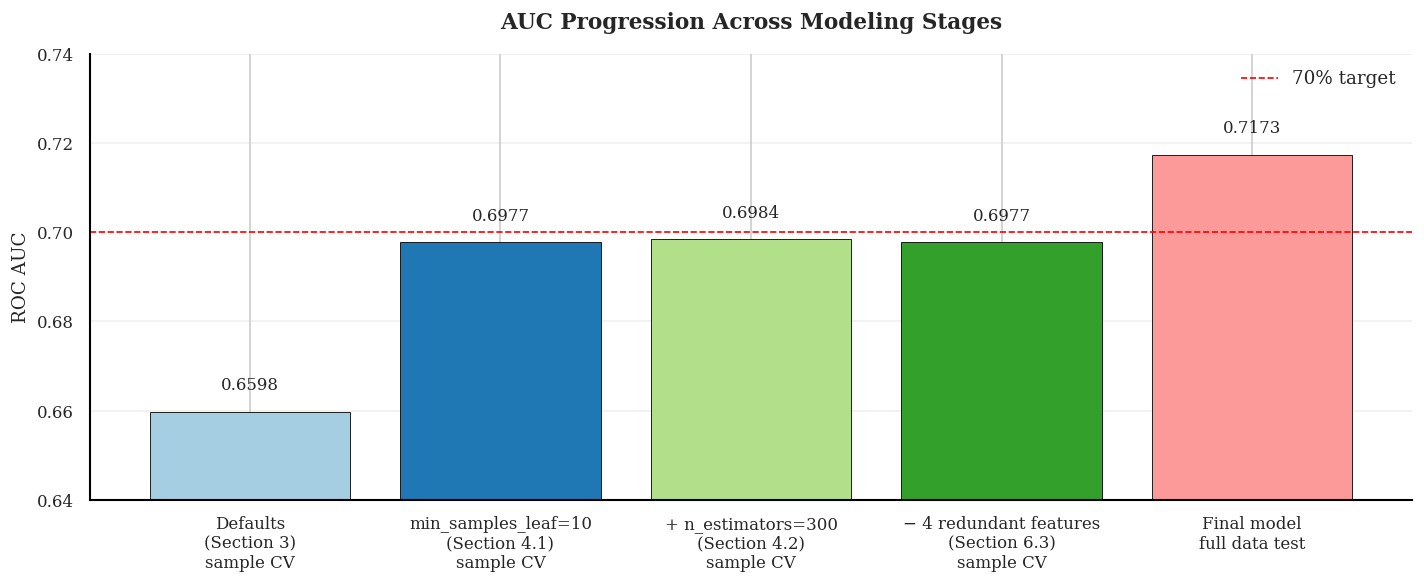

In [46]:
# 7.2 AUC progression chart
progression_stages = [
    "Defaults\n(Section 3)\nsample CV",
    "min_samples_leaf=10\n(Section 4.1)\nsample CV",
    "+ n_estimators=300\n(Section 4.2)\nsample CV",
    "− 4 redundant features\n(Section 6.3)\nsample CV",
    "Final model\nfull data test",
]
progression_auc = [0.6598, 0.6977, 0.6984, 0.6977, 0.7173]

# Seaborn Paired palette gives 5 distinct colors
bar_colors = sns.color_palette("Paired", n_colors=5)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(progression_stages, progression_auc, color=bar_colors, edgecolor="black", linewidth=0.5)

# Annotate each bar with its AUC value; lifted higher off the bar top
for bar, auc in zip(bars, progression_auc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f"{auc:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        family="serif",
    )

# 70% target reference line
ax.axhline(y=0.70, color="red", linestyle="--", linewidth=1, label="70% target")

# Academic-style title and axis labels (serif font)
ax.set_ylabel("ROC AUC", fontsize=11, family="serif")
ax.set_title("AUC Progression Across Modeling Stages", fontsize=13, pad=15, family="serif", fontweight="bold")
ax.set_ylim(0.64, 0.74)

# Apply serif font to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("serif")
    label.set_fontsize("10")

# Legend without border
legend = ax.legend(loc="upper right", frameon=False, prop={"family": "serif"})

# Keep only left and bottom spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Threshold Selection on Validation Set

The default 0.5 threshold is suboptimal for imbalanced classification. To pick a threshold without overfitting to the test set, the training data gets split further into a fit-portion (80%), and a validation portion (20%). The model fits
on the fit-portion only, and the threshold that maximizes F1 on validation becomes the operating threshold. This isolates threshold selection from test evaluation. The fixed threshold is then applied to the held-out test set to report a
F1.

In [51]:
# 7.3 Threshold selection on validation set
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# Split train into fit and validation
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.20,
    stratify=y_train_final,
    random_state=RANDOM_SEED,
)

# Build a fresh pipeline for threshold selection so we don't overwrite the final model
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

preprocessor_threshold = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_columns_final),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=10,
            sparse_output=False,
            dtype=np.float32,
        ), low_cardinality_columns_final),
        ("target", TargetEncoder(
            target_type="binary",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        ), high_cardinality_columns_final),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
pipeline_threshold_select = Pipeline(
    steps=[
        ("preprocess", preprocessor_threshold),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            min_samples_leaf=10,
            max_features="sqrt",
        )),
    ],
)

# Fit and select threshold
pipeline_threshold_select.fit(X_train_fit, y_train_fit)
y_val_proba = pipeline_threshold_select.predict_proba(X_val)[:, 1]

threshold_grid = np.arange(0.01, 1.0, 0.01)
f1_scores_val = []
for threshold in threshold_grid:
    y_val_pred = (y_val_proba >= threshold).astype(int)
    f1_scores_val.append(f1_score(y_val, y_val_pred, zero_division=0))
f1_scores_val = np.array(f1_scores_val)

optimal_index = f1_scores_val.argmax()
optimal_threshold = threshold_grid[optimal_index]
optimal_f1_val = f1_scores_val[optimal_index]

# Apply the validation-chosen threshold to the original test predictions
y_test_pred_at_optimal = (y_test_proba_final >= optimal_threshold).astype(int)
f1_test_at_optimal = f1_score(y_test_final, y_test_pred_at_optimal, zero_division=0)

print(f"optimal threshold (val) : {optimal_threshold:.3f}")
print(f"best F1 on val          : {optimal_f1_val:.4f}")
print(f"F1 on test (fixed thr)  : {f1_test_at_optimal:.4f}")

optimal threshold (val) : 0.480
best F1 on val          : 0.4693
F1 on test (fixed thr)  : 0.4696


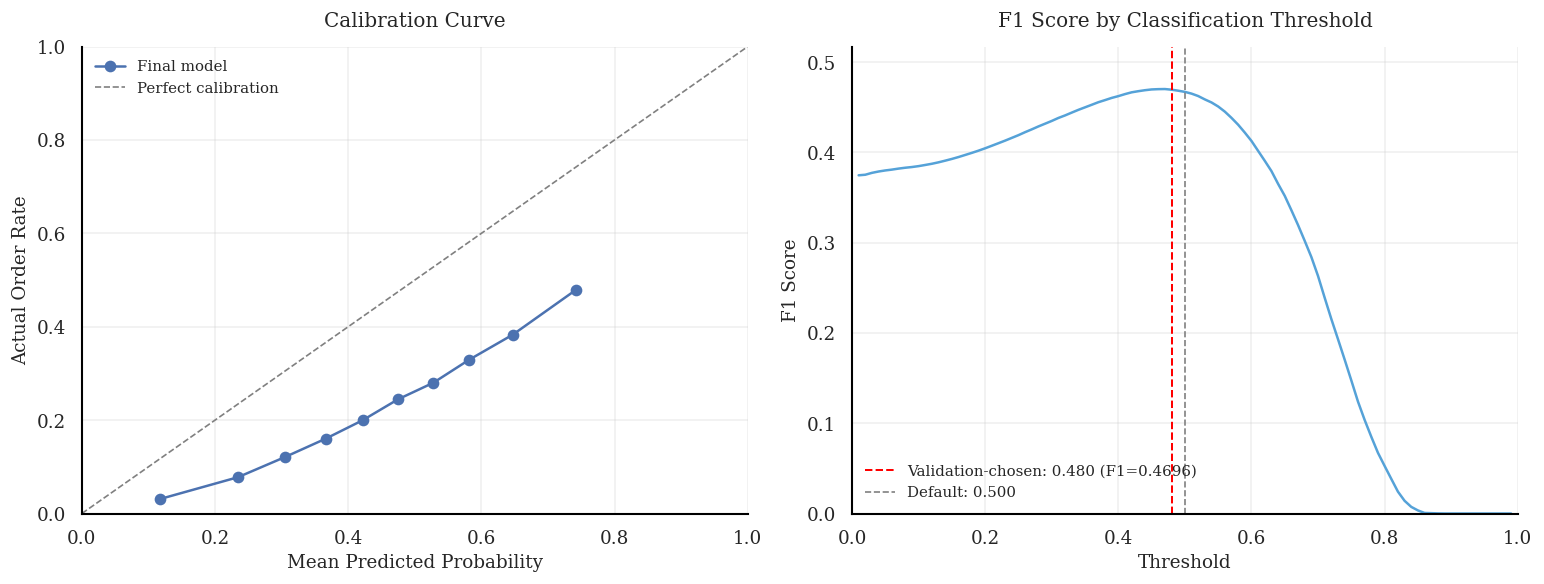

In [53]:
# 7.4 Calibration curve and F1 by threshold
from sklearn.calibration import calibration_curve

# Calibration curve from the held-out test predictions
prob_true, prob_pred = calibration_curve(
    y_test_final,
    y_test_proba_final,
    n_bins=10,
    strategy="quantile",
)

# F1 across all thresholds on the test set (for visualization)
threshold_grid_chart = np.arange(0.01, 1.0, 0.01)
f1_scores_chart = []
for threshold in threshold_grid_chart:
    y_pred_at_threshold = (y_test_proba_final >= threshold).astype(int)
    f1_scores_chart.append(f1_score(y_test_final, y_pred_at_threshold, zero_division=0))
f1_scores_chart = np.array(f1_scores_chart)

# Build the figure with two side-by-side panels
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: calibration curve
ax_left = axes[0]
ax_left.plot(prob_pred, prob_true, marker="o", color="#4C72B0", linewidth=1.5, markersize=6, label="Final model")
ax_left.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfect calibration")
ax_left.set_xlim(0, 1)
ax_left.set_ylim(0, 1)
ax_left.set_xlabel("Mean Predicted Probability", family="serif", fontsize=11)
ax_left.set_ylabel("Actual Order Rate", family="serif", fontsize=11)
ax_left.set_title("Calibration Curve", family="serif", fontsize=12, pad=12)
ax_left.legend(loc="upper left", frameon=False, prop={"family": "serif", "size":9})
ax_left.grid(alpha=0.3)
for label in ax_left.get_xticklabels() + ax_left.get_yticklabels():
    label.set_family("serif")
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.spines["left"].set_color("black")
ax_left.spines["bottom"].set_color("black")

# Right panel: F1 vs threshold
ax_right = axes[1]
ax_right.plot(threshold_grid_chart, f1_scores_chart, color="#55A2D8", linewidth=1.5)
ax_right.axvline(
    x=optimal_threshold,  # 0.480 from Section 7.3
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Validation-chosen: {optimal_threshold:.3f} (F1={f1_test_at_optimal:.4f})"
)
ax_right.axvline(x=0.5, color="gray", linestyle="--", linewidth=1, label="Default: 0.500")
ax_right.set_xlim(0, 1)
ax_right.set_ylim(0, max(f1_scores_chart) * 1.1)
ax_right.set_xlabel("Threshold", family="serif", fontsize=11)
ax_right.set_ylabel("F1 Score", family="serif", fontsize=11)
ax_right.set_title("F1 Score by Classification Threshold", family="serif", fontsize=12, pad=12)
ax_right.legend(loc="lower left", frameon=False, prop={"family": "serif", "size":9})
ax_right.grid(alpha=0.3)
for label in ax_right.get_xticklabels() + ax_right.get_yticklabels():
    label.set_family("serif")
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)
ax_right.spines["left"].set_color("black")
ax_right.spines["bottom"].set_color("black")

plt.tight_layout()
plt.show()

### 7.4 Final Observation

The classifier reached a test ROC AUC of 0.7173 on the held-out 451,879-row test set, clearing the 70% target. The path to that result followed three stages, each contributing measurably to the final number.

Stage one was hyperparameter tuning. Default Random Forest settings produced a 0.6598 cross-validated AUC on the sample, well below the target. Section 4.1 tested four combinations of `max_depth` and `min_samples_leaf`. The single change
that mattered was raising `min_samples_leaf` from 1 to 10, which forced leaves to represent at least ten training rows and lifted AUC to 0.6977. Section 4.2 then tested whether more trees, or a wider feature consideration would help
further. They did not. The 9-combination grid produced a 0.6984 best score, a 0.0007 lift in noise territory. Tuning effectively converged after one parameter change.

Stage two was feature engineering analysis. Section 5 compared impurity-based and permutation-based feature importance and found that the model relied mainly on three target-encoded categorical (`group`, `manufacturer`, `category`) plus
the engineered `price_over_rrp` ratio. The Spearman cluster identified one redundant group: three pricing-vs-competitor variants. Their combined importance (0.0094) closely matched `price_over_rrp` alone (0.0098), confirming the three
carried duplicate signal.

Stage three was three feature experiments. Adding `unit` as a categorical produced no measurable lift (+0.0000). Adding an explicit `adFlag_campaignIndex` interaction in form of 1_A as and example, also did not help (+0.0001), because
tree-based models discover such interactions implicitly through sequential splits. Dropping the four redundant features (the three pricing comparisons, and the `price_diff_vs_previous_available_day`) preserved AUC at 0.6977 while reducing
the feature count from 22 to 18.

The simplified 18-feature configuration moved to full data for final evaluation. Test AUC reached 0.7173, a 0.019 gain over the sample CV result, consistent with the additional support tree-based models gain from larger training sets.

A summary of the AUC progression:

| Stage         | Configuration                           |    AUC | Data           |
|:--------------|:----------------------------------------|-------:|:---------------|
| Default       | sklearn defaults, 22 features           | 0.6598 | sample CV      |
| Round 1 tuned | min_samples_leaf=10                     | 0.6977 | sample CV      |
| Round 2 tuned | + n_estimators=300, max_features='sqrt' | 0.6984 | sample CV      |
| Simplified    | 18 features (4 dropped)                 | 0.6977 | sample CV      |
| Final model   | 18 features, locked configuration       | 0.7173 | full-data test |

The two diagnostic charts in Section 7 deepened the headline result. The calibration curve revealed that predicted probabilities sit systematically below actual order rates across all bins, by 9 to 26 percentage points. The model ranks
rows correctly (the AUC measures this) but inflates its probability estimates. The cause is `class_weight='balanced_subsample'`, which trains the model on a synthetic 50/50 distribution rather than the actual 23/77 distribution. If
predicted probabilities were needed as confidence scores in a deployment scenario, other methods would fits better.

The F1-by-threshold curve confirmed that the default 0.500 threshold was nearly optimal. Tuning the threshold on a held-out validation portion of the training set selected 0.480, which lifted F1 from 0.4671 to 0.4696 on the test set: a
0.0025 gain, in noise. The threshold curve also showed F1 is broadly stable in the 0.40 to 0.55 range, indicating the model is not threshold-sensitive in normal operating conditions. Beyond 0.55 the curve drops sharply as the strictness
pushes recall toward zero.

The final feature set carried thirteen numeric columns, two low-cardinality categorical (`pharmForm`, `weekday`), and three high-cardinality target-encoded columns (`category`, `manufacturer`, `group`). The classifier ran with
`n_estimators=300`, `min_samples_leaf=10`, `max_features='sqrt'`, `max_depth=None`, and `class_weight='balanced_subsample'`. Among these, only `min_samples_leaf=10` came from active tuning; the rest were sklearn defaults that the tuning
search confirmed as optimal.

Three things this work establishes. First, the bulk of model performance came from a single hyperparameter change, not from vast feature engineering. Trees discover most interaction effects implicitly. Second, removing four redundant
features simplified the model without cost, suggesting we produced more variants than the model needed. Third, the model achieves strong ranking performance (AUC 0.7173) but generates uncalibrated probabilities, an important limitation for
any downstream use that relies on probability estimates rather than rankings.

In [54]:
# Save the trained pipeline
import joblib

model_path = DATA_PROCESSED / "rfc_final_model.joblib"
joblib.dump(pipeline_final, model_path)

print(f"saved model to       : {model_path.relative_to(PROJECT_ROOT)}")
print(f"file size            : {model_path.stat().st_size / (1024 * 1024):.1f} MB")

saved model to       : data\processed\rfc_final_model.joblib
file size            : 1368.5 MB
